First of all going to pick the candidates

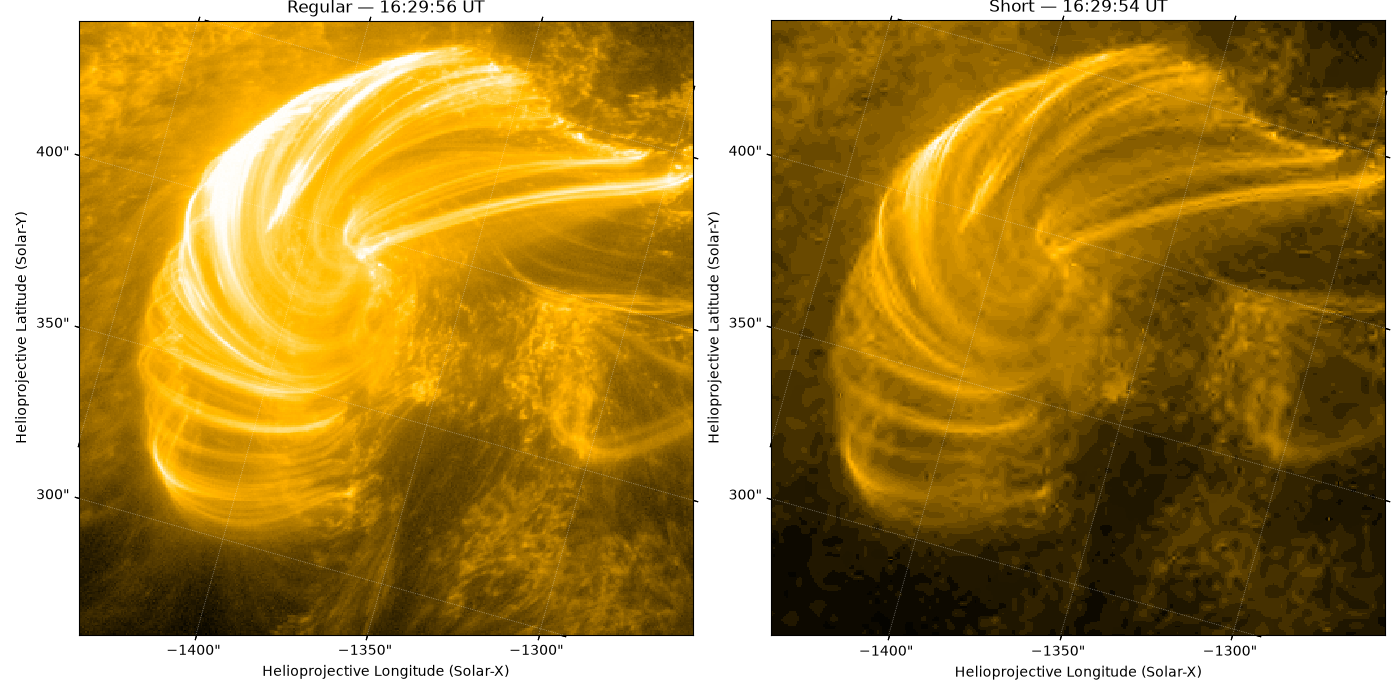

In [ ]:
%matplotlib widget

import sunpy.map
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord


regular_map = sunpy.map.Map(
    "../data/20260820T154500/"
    "solo_L2_eui-hrieuv174-image_20260820T162956285_V00.fits"
)

short_map = sunpy.map.Map(
    "../data/20260820T154500/"
    "solo_L2_eui-hrieuv174-image-short_20260820T162954285_V00.fits"
)

#zoom
zoom_width = 150 * u.arcsec
zoom_height = 150 * u.arcsec

bottom_left = SkyCoord(
    -1370 * u.arcsec - zoom_width / 2,
    375 * u.arcsec - zoom_height / 2,
    frame=regular_map.coordinate_frame
)

top_right = SkyCoord(
    -1370 * u.arcsec + zoom_width / 2,
    375 * u.arcsec + zoom_height / 2,
    frame=regular_map.coordinate_frame
)

regular_zoom = regular_map.submap(
    bottom_left,
    top_right=top_right
)

short_zoom = short_map.submap(
    bottom_left,
    top_right=top_right
)


fig = plt.figure(figsize=(14, 7))

ax1 = fig.add_subplot(
    1, 2, 1,
    projection=regular_zoom.wcs
)

ax2 = fig.add_subplot(
    1, 2, 2,
    projection=short_zoom.wcs
)

regular_zoom.plot(axes=ax1)
short_zoom.plot(axes=ax2)

ax1.set_title(
    f"Regular — {regular_map.date.iso[11:19]} UT"
)

ax2.set_title(
    f"Short — {short_map.date.iso[11:19]} UT"
)

plt.tight_layout()

plt.show()

Candidate loop coords: 
1) -1412'' 341''
2) -1383'' 445''
3) -1414'' 360''
4) -1399'' 325'' (this seems to be 2 loops)

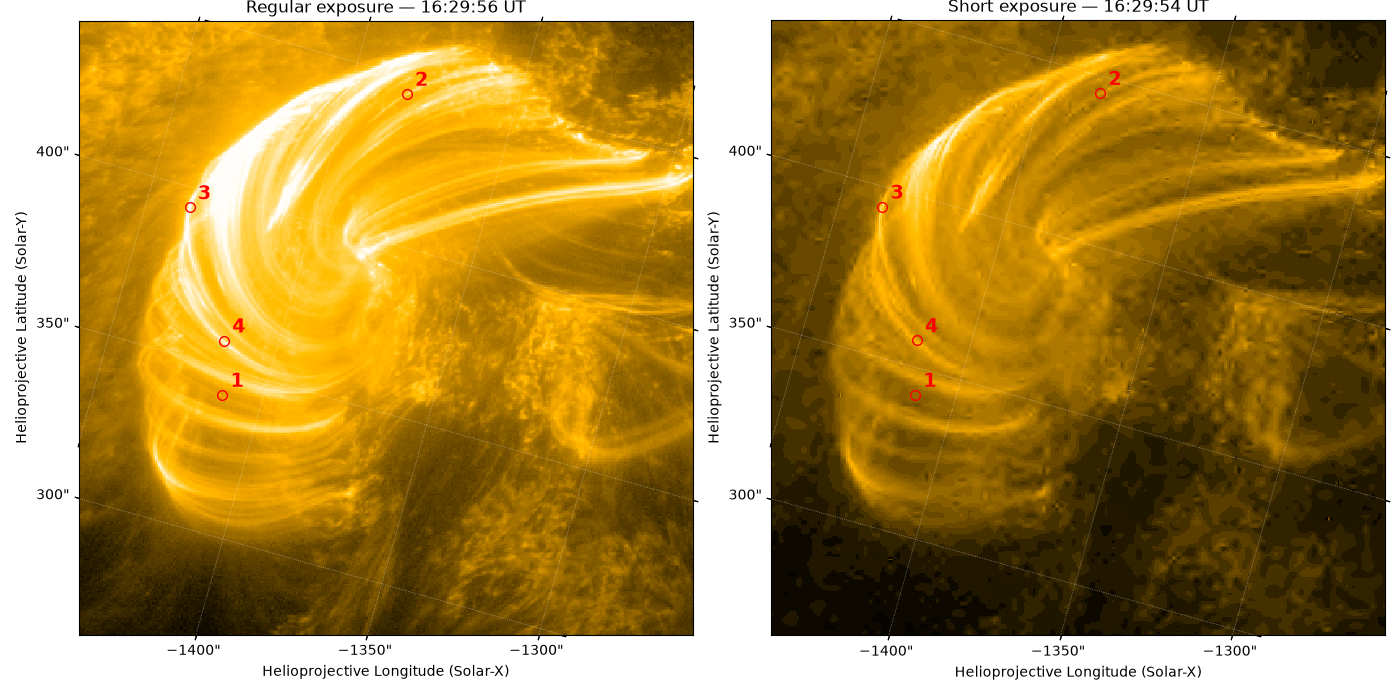

In [ ]:
%matplotlib widget

import sunpy.map
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord


regular_file = (
    "../data/20260820T154500/"
    "solo_L2_eui-hrieuv174-image_20260820T162956285_V00.fits"
)

regular_map = sunpy.map.Map(regular_file)


short_file = (
    "../data/20260820T154500/"
    "solo_L2_eui-hrieuv174-image-short_20260820T162954285_V00.fits"
)

short_map = sunpy.map.Map(short_file)


candidate_coords = [
    (-1412, 342),   # Loop 1
    (-1383, 445),   # Loop 2
    (-1437, 394),   # Loop 3
    (-1416, 358),   # Loop 4
]


candidates = SkyCoord(
    [x * u.arcsec for x, y in candidate_coords],
    [y * u.arcsec for x, y in candidate_coords],
    frame=regular_map.coordinate_frame
)



zoom_width = 150 * u.arcsec
zoom_height = 150 * u.arcsec

bottom_left = SkyCoord(
    -1370 * u.arcsec - zoom_width / 2,
    375 * u.arcsec - zoom_height / 2,
    frame=regular_map.coordinate_frame
)

top_right = SkyCoord(
    -1370 * u.arcsec + zoom_width / 2,
    375 * u.arcsec + zoom_height / 2,
    frame=regular_map.coordinate_frame
)

regular_zoom = regular_map.submap(
    bottom_left,
    top_right=top_right
)

short_zoom = short_map.submap(
    bottom_left,
    top_right=top_right
)


fig = plt.figure(figsize=(14, 7))

ax1 = fig.add_subplot(
    1, 2, 1,
    projection=regular_zoom.wcs
)

ax2 = fig.add_subplot(
    1, 2, 2,
    projection=short_zoom.wcs
)

regular_zoom.plot(axes=ax1)
short_zoom.plot(axes=ax2)


#candidate markers
for i, coord in enumerate(candidates, start=1):

    #convert solar coordinates to pixels
    x1, y1 = regular_zoom.world_to_pixel(coord)
    x2, y2 = short_zoom.world_to_pixel(coord)

    ax1.plot(
        x1.value,
        y1.value,
        "ro",
        markersize=7,
        markerfacecolor="none"
    )

    ax1.text(
        x1.value + 5,
        y1.value + 5,
        str(i),
        color="red",
        fontsize=14,
        fontweight="bold"
    )

    ax2.plot(
        x2.value,
        y2.value,
        "ro",
        markersize=7,
        markerfacecolor="none"
    )

    ax2.text(
        x2.value + 5,
        y2.value + 5,
        str(i),
        color="red",
        fontsize=14,
        fontweight="bold"
    )


ax1.set_title(
    f"Regular exposure — {regular_map.date.iso[11:19]} UT"
)

ax2.set_title(
    f"Short exposure — {short_map.date.iso[11:19]} UT"
)


plt.tight_layout()


plt.savefig(
    "../figures/week02_candidate_loops.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

LOOP 1

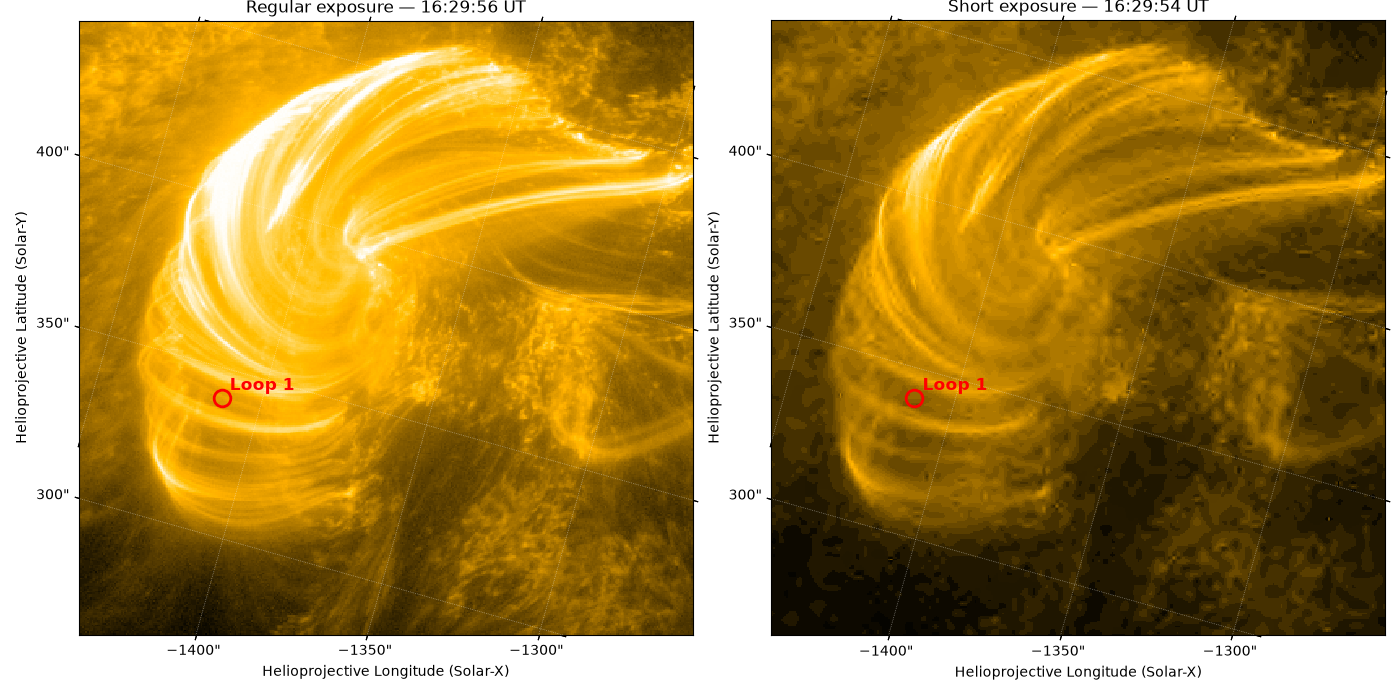

In [ ]:
%matplotlib widget
%matplotlib widget

import sunpy.map
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord

regular_file = (
    "../data/20260820T154500/"
    "solo_L2_eui-hrieuv174-image_20260820T162956285_V00.fits"
)

eui_map = sunpy.map.Map(regular_file)


short_file = (
    "../data/20260820T154500/"
    "solo_L2_eui-hrieuv174-image-short_20260820T162954285_V00.fits"
)

short_map = sunpy.map.Map(short_file)


zoom_width = 150 * u.arcsec
zoom_height = 150 * u.arcsec

bottom_left = SkyCoord(
    -1370 * u.arcsec - zoom_width / 2,
    375 * u.arcsec - zoom_height / 2,
    frame=eui_map.coordinate_frame
)

top_right = SkyCoord(
    -1370 * u.arcsec + zoom_width / 2,
    375 * u.arcsec + zoom_height / 2,
    frame=eui_map.coordinate_frame
)

zoomed_map = eui_map.submap(
    bottom_left,
    top_right=top_right
)

short_zoom = short_map.submap(
    bottom_left,
    top_right=top_right
)


loop1 = SkyCoord(
    -1412 * u.arcsec,
    341 * u.arcsec,
    frame=eui_map.coordinate_frame
)


fig = plt.figure(figsize=(14, 7))

ax1 = fig.add_subplot(
    1, 2, 1,
    projection=zoomed_map.wcs
)

ax2 = fig.add_subplot(
    1, 2, 2,
    projection=short_zoom.wcs
)

zoomed_map.plot(axes=ax1)
short_zoom.plot(axes=ax2)


x1, y1 = zoomed_map.world_to_pixel(loop1)

ax1.plot(
    x1.value,
    y1.value,
    "ro",
    markersize=12,
    markerfacecolor="none",
    markeredgewidth=2
)

ax1.text(
    x1.value + 5,
    y1.value + 5,
    "Loop 1",
    color="red",
    fontsize=12,
    fontweight="bold"
)


x2, y2 = short_zoom.world_to_pixel(loop1)

ax2.plot(
    x2.value,
    y2.value,
    "ro",
    markersize=12,
    markerfacecolor="none",
    markeredgewidth=2
)

ax2.text(
    x2.value + 5,
    y2.value + 5,
    "Loop 1",
    color="red",
    fontsize=12,
    fontweight="bold"
)


ax1.set_title(
    f"Regular exposure — {eui_map.date.iso[11:19]} UT"
)

ax2.set_title(
    f"Short exposure — {short_map.date.iso[11:19]} UT"
)

plt.tight_layout()
plt.show()

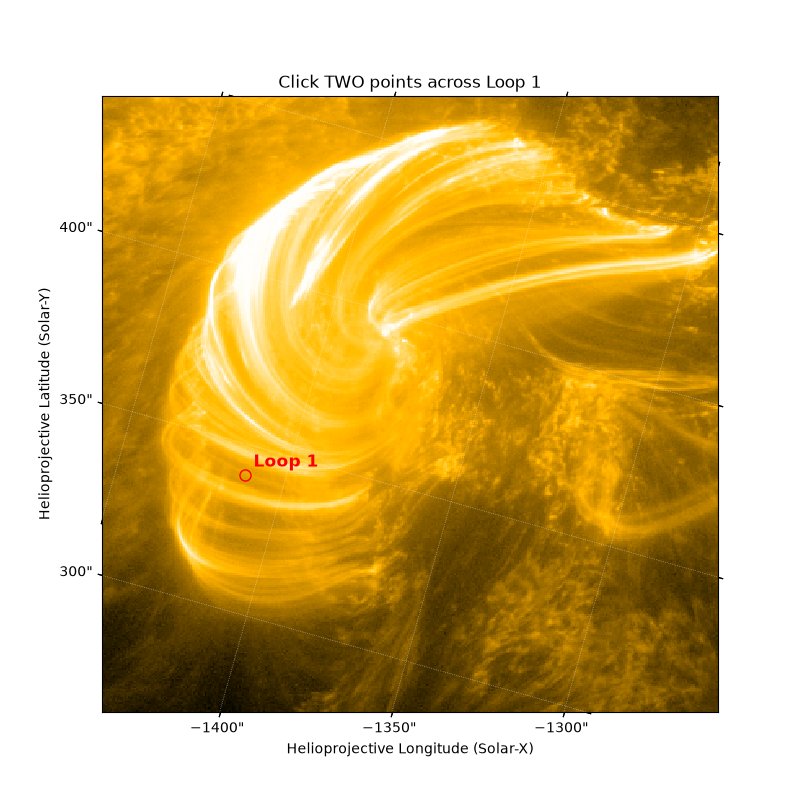

In [ ]:

#click TWO points across Loop 1

clicked_points = []

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection=zoomed_map.wcs)

zoomed_map.plot(axes=ax)

#show Loop 1
x, y = zoomed_map.world_to_pixel(loop1)

ax.plot(
    x.value,
    y.value,
    "ro",
    markersize=8,
    markerfacecolor="none"
)

ax.text(
    x.value + 5,
    y.value + 5,
    "Loop 1",
    color="red",
    fontsize=12,
    fontweight="bold"
)

ax.set_title("Click TWO points across Loop 1")

def onclick(event):
    if event.inaxes != ax:
        return

    if event.xdata is None or event.ydata is None:
        return

    #only allow two points
    if len(clicked_points) >= 2:
        return

    clicked_points.append((event.xdata, event.ydata))

    ax.plot(
        event.xdata,
        event.ydata,
        "go",
        markersize=8
    )

    ax.text(
        event.xdata + 3,
        event.ydata + 3,
        f"{len(clicked_points)}",
        color="green",
        fontsize=12,
        fontweight="bold"
    )

    fig.canvas.draw_idle()

    print(
        f"Point {len(clicked_points)}: "
        f"x={event.xdata:.2f}, y={event.ydata:.2f}"
    )

    if len(clicked_points) == 2:
        print("\nTwo points selected!")
        print("You can now use these to extract the transverse intensity profile.")

fig.canvas.mpl_connect("button_press_event", onclick)

plt.show()

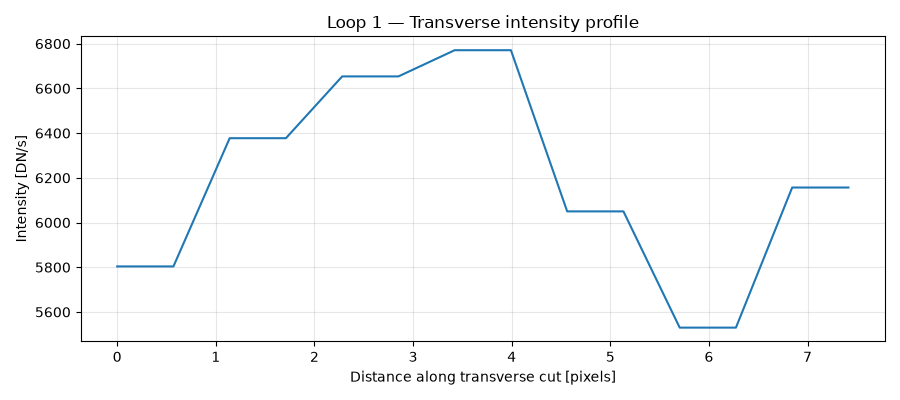

In [ ]:

#intensity profile
import numpy as np
import matplotlib.pyplot as plt

#get the two clicked pixel coordinates
(x1, y1), (x2, y2) = clicked_points

n_samples = int(np.hypot(x2 - x1, y2 - y1)) * 2

x_pixels = np.linspace(x1, x2, n_samples)
y_pixels = np.linspace(y1, y2, n_samples)

#convert to integer pixel indices
x_idx = np.round(x_pixels).astype(int)
y_idx = np.round(y_pixels).astype(int)

#keep only pixels inside the image
valid = (
    (x_idx >= 0) &
    (x_idx < zoomed_map.data.shape[1]) &
    (y_idx >= 0) &
    (y_idx < zoomed_map.data.shape[0])
)

x_idx = x_idx[valid]
y_idx = y_idx[valid]

#extract intensity
intensity = zoomed_map.data[y_idx, x_idx]

#distance along cut in pixels
distance = np.linspace(
    0,
    np.hypot(x2 - x1, y2 - y1),
    len(intensity)
)

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(
    distance,
    intensity,
    linewidth=1.5
)

ax.set_xlabel("Distance along transverse cut [pixels]")
ax.set_ylabel("Intensity [DN/s]")
ax.set_title("Loop 1 — Transverse intensity profile")

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

#load corresponding short-exposure image

short_file = (
    "../data/20260820T154500/"
    "solo_L2_eui-hrieuv174-image-short_20260820T162954285_V00.fits"
)

short_map = sunpy.map.Map(short_file)

short_zoom = short_map.submap(
    bottom_left,
    top_right=top_right
)

print("Regular:", eui_map.date.iso)
print("Short:  ", short_map.date.iso)

Regular: 2026-08-20 16:29:56.285
Short:   2026-08-20 16:29:54.285


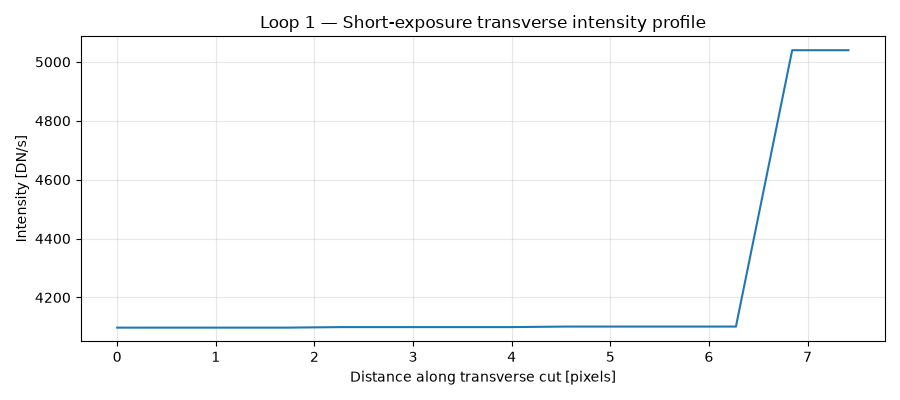

In [ ]:
#short-exposure transverse profile, same physical cut as the regular exposure

cut_coords = zoomed_map.pixel_to_world(
    np.array([x1, x2]) * u.pix,
    np.array([y1, y2]) * u.pix
)

#convert solar coordinates to pixels in the short zoom
short_x1, short_y1 = short_zoom.world_to_pixel(cut_coords[0])
short_x2, short_y2 = short_zoom.world_to_pixel(cut_coords[1])

short_x1 = short_x1.value
short_y1 = short_y1.value
short_x2 = short_x2.value
short_y2 = short_y2.value

n_samples_short = int(
    np.hypot(
        short_x2 - short_x1,
        short_y2 - short_y1
    )
) * 2

short_x_pixels = np.linspace(
    short_x1,
    short_x2,
    n_samples_short
)

short_y_pixels = np.linspace(
    short_y1,
    short_y2,
    n_samples_short
)

short_x_idx = np.round(short_x_pixels).astype(int)
short_y_idx = np.round(short_y_pixels).astype(int)

valid = (
    (short_x_idx >= 0) &
    (short_x_idx < short_zoom.data.shape[1]) &
    (short_y_idx >= 0) &
    (short_y_idx < short_zoom.data.shape[0])
)

short_x_idx = short_x_idx[valid]
short_y_idx = short_y_idx[valid]

short_intensity = short_zoom.data[
    short_y_idx,
    short_x_idx
]

short_distance = np.linspace(
    0,
    np.hypot(
        short_x2 - short_x1,
        short_y2 - short_y1
    ),
    len(short_intensity)
)


fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(
    short_distance,
    short_intensity,
    linewidth=1.5
)

ax.set_xlabel("Distance along transverse cut [pixels]")
ax.set_ylabel("Intensity [DN/s]")
ax.set_title("Loop 1 — Short-exposure transverse intensity profile")

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

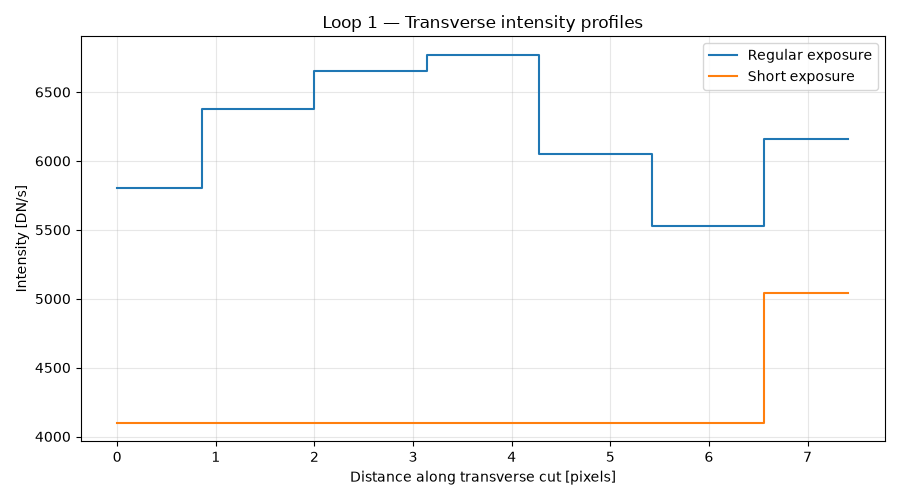

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    distance,
    intensity,
    linewidth=1.5,
    drawstyle="steps-mid",
    label="Regular exposure"
)

ax.plot(
    short_distance,
    short_intensity,
    linewidth=1.5,
    drawstyle="steps-mid",
    label="Short exposure"
)

ax.set_xlabel("Distance along transverse cut [pixels]")
ax.set_ylabel("Intensity [DN/s]")

ax.set_title("Loop 1 — Transverse intensity profiles")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../figures/loop1_transverse_profiles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [149]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


#gaussian + constant background
def gaussian(x, A, x0, sigma, B):
    return (
        A * np.exp(-(x - x0)**2 / (2 * sigma**2))
        + B
    )


#select only the Loop 1 feature
fit_mask = (
    (distance >= 0.55) &
    (distance <= 4.6)
)

x_loop = distance[fit_mask]
y_loop = intensity[fit_mask]


#initial guesses
p0 = [
    y_loop.max() - y_loop.min(),
    x_loop[np.argmax(y_loop)],
    0.5,
    y_loop.min()
]


#fit
popt, pcov = curve_fit(
    gaussian,
    x_loop,
    y_loop,
    p0=p0
)


A, x0, sigma, B = popt


#FWHM
fwhm_pixels_1 = (
    2 * np.sqrt(2 * np.log(2)) * abs(sigma)
)


print(f"Gaussian centre = {x0:.3f} pixels")
print(f"Sigma = {abs(sigma):.3f} pixels")
print(f"Background = {B:.2f} DN/s")
print(f"FWHM = {fwhm_pixels_1:.3f} pixels")

Gaussian centre = 2.849 pixels
Sigma = 64.604 pixels
Background = -1499204.70 DN/s
FWHM = 152.131 pixels


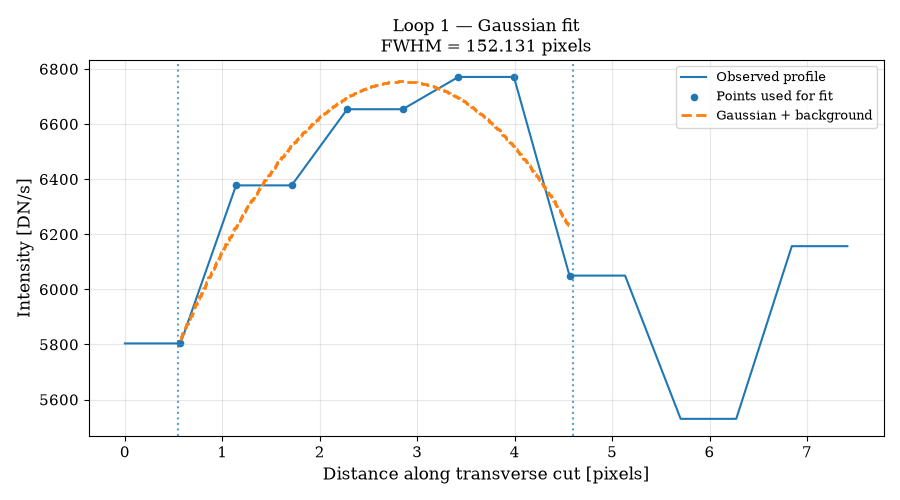

In [150]:
x_fit = np.linspace(
    x_loop.min(),
    x_loop.max(),
    300
)

y_fit = gaussian(
    x_fit,
    A,
    x0,
    sigma,
    B
)


fig, ax = plt.subplots(figsize=(9, 5))


ax.plot(
    distance,
    intensity,
    label="Observed profile"
)

ax.scatter(
    x_loop,
    y_loop,
    s=20,
    label="Points used for fit"
)


ax.plot(
    x_fit,
    y_fit,
    "--",
    linewidth=2,
    drawstyle="steps-mid",
    label="Gaussian + background"
)

ax.axvline(
    0.55,
    linestyle=":",
    alpha=0.7
)

ax.axvline(
    4.6,
    linestyle=":",
    alpha=0.7
)

ax.set_xlabel("Distance along transverse cut [pixels]")
ax.set_ylabel("Intensity [DN/s]")

ax.set_title(
    f"Loop 1 — Gaussian fit\n"
    f"FWHM = {fwhm_pixels_1:.3f} pixels"
)

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../figures/loop1_gaussian_fit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

LOOP 2 

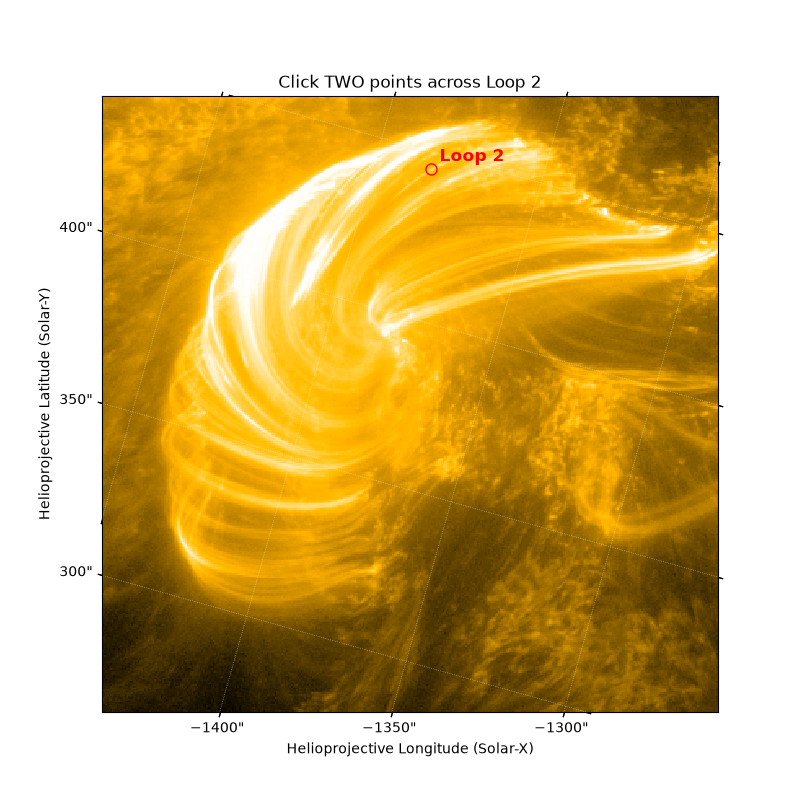

In [ ]:

clicked_points = []

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection=zoomed_map.wcs)

zoomed_map.plot(axes=ax)


loop2 = SkyCoord(
    -1383 * u.arcsec,
    445 * u.arcsec,
    frame=eui_map.coordinate_frame
)

x, y = zoomed_map.world_to_pixel(loop2)

ax.plot(
    x.value,
    y.value,
    "ro",
    markersize=8,
    markerfacecolor="none"
)

ax.text(
    x.value + 5,
    y.value + 5,
    "Loop 2",
    color="red",
    fontsize=12,
    fontweight="bold"
)

ax.set_title("Click TWO points across Loop 2")

def onclick(event):
    if event.inaxes != ax:
        return

    if event.xdata is None or event.ydata is None:
        return

    
    if len(clicked_points) >= 2:
        return

    clicked_points.append((event.xdata, event.ydata))

    ax.plot(
        event.xdata,
        event.ydata,
        "go",
        markersize=8
    )

    ax.text(
        event.xdata + 3,
        event.ydata + 3,
        f"{len(clicked_points)}",
        color="green",
        fontsize=12,
        fontweight="bold"
    )

    fig.canvas.draw_idle()

    print(
        f"Point {len(clicked_points)}: "
        f"x={event.xdata:.2f}, y={event.ydata:.2f}"
    )

    if len(clicked_points) == 2:
        print("\nTwo points selected!")
        print("You can now use these to extract the transverse intensity profile.")

fig.canvas.mpl_connect("button_press_event", onclick)

plt.show()

Using the following transverse cut:
Point 1: x=84.30, y=174.88
Point 2: x=93.51, y=184.08
Loop 2 profile: 100 samples
Loop 2 short profile: 100 samples


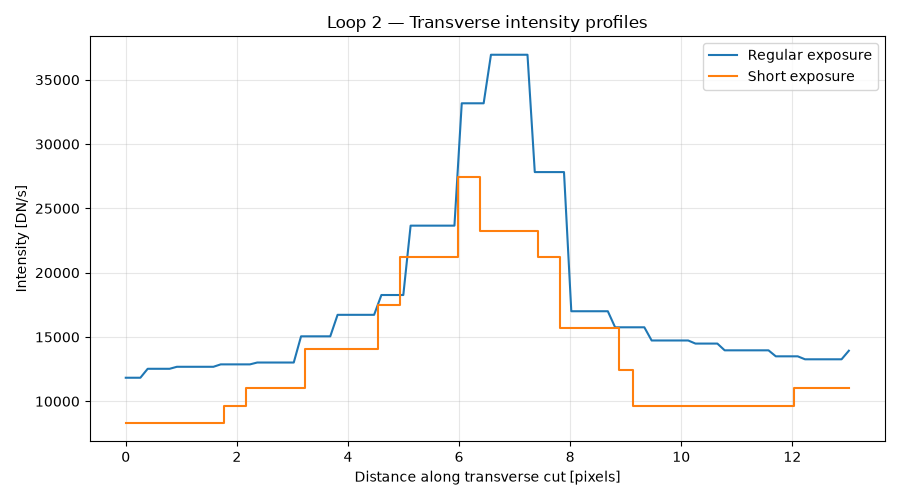

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u


if len(clicked_points) != 2:
    raise ValueError("Please click exactly TWO points first.")

(x1, y1), (x2, y2) = clicked_points

print("Using the following transverse cut:")
print(f"Point 1: x={x1:.2f}, y={y1:.2f}")
print(f"Point 2: x={x2:.2f}, y={y2:.2f}")


n_samples = 100

x_pixels = np.linspace(x1, x2, n_samples)
y_pixels = np.linspace(y1, y2, n_samples)


x_idx = np.round(x_pixels).astype(int)
y_idx = np.round(y_pixels).astype(int)


valid = (
    (x_idx >= 0) &
    (x_idx < zoomed_map.data.shape[1]) &
    (y_idx >= 0) &
    (y_idx < zoomed_map.data.shape[0])
)

x_idx = x_idx[valid]
y_idx = y_idx[valid]


intensity_2 = zoomed_map.data[y_idx, x_idx]


distance_2 = np.linspace(
    0,
    np.hypot(x2 - x1, y2 - y1),
    len(intensity_2)
)

print(f"Loop 2 profile: {len(intensity_2)} samples")


cut_coords_2 = zoomed_map.pixel_to_world(
    np.array([x1, x2]) * u.pix,
    np.array([y1, y2]) * u.pix
)

short_x1, short_y1 = short_zoom.world_to_pixel(cut_coords_2[0])
short_x2, short_y2 = short_zoom.world_to_pixel(cut_coords_2[1])

short_x1 = short_x1.value
short_y1 = short_y1.value
short_x2 = short_x2.value
short_y2 = short_y2.value


n_samples_short_2 = 100

short_x_pixels = np.linspace(
    short_x1,
    short_x2,
    n_samples_short_2
)

short_y_pixels = np.linspace(
    short_y1,
    short_y2,
    n_samples_short_2
)


short_x_idx = np.round(short_x_pixels).astype(int)
short_y_idx = np.round(short_y_pixels).astype(int)

valid = (
    (short_x_idx >= 0) &
    (short_x_idx < short_zoom.data.shape[1]) &
    (short_y_idx >= 0) &
    (short_y_idx < short_zoom.data.shape[0])
)

short_x_idx = short_x_idx[valid]
short_y_idx = short_y_idx[valid]


short_intensity_2 = short_zoom.data[
    short_y_idx,
    short_x_idx
]


short_distance_2 = np.linspace(
    0,
    np.hypot(
        short_x2 - short_x1,
        short_y2 - short_y1
    ),
    len(short_intensity_2)
)

print(f"Loop 2 short profile: {len(short_intensity_2)} samples")


fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    distance_2,
    intensity_2,
    linewidth=1.5,
    label="Regular exposure"
)

ax.plot(
    short_distance_2,
    short_intensity_2,
    linewidth=1.5,
    drawstyle="steps-mid",
    label="Short exposure"
)

ax.set_xlabel("Distance along transverse cut [pixels]")
ax.set_ylabel("Intensity [DN/s]")

ax.set_title("Loop 2 — Transverse intensity profiles")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../figures/loop2_transverse_profiles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

REGULAR EXPOSURE
Gaussian centre = 6.788 pixels
Sigma = 0.830 pixels
Background = 17261.97 DN/s
FWHM = 1.955 pixels

SHORT EXPOSURE
Gaussian centre = 6.419 pixels
Sigma = 1.478 pixels
Background = 9342.98 DN/s
FWHM = 3.480 pixels


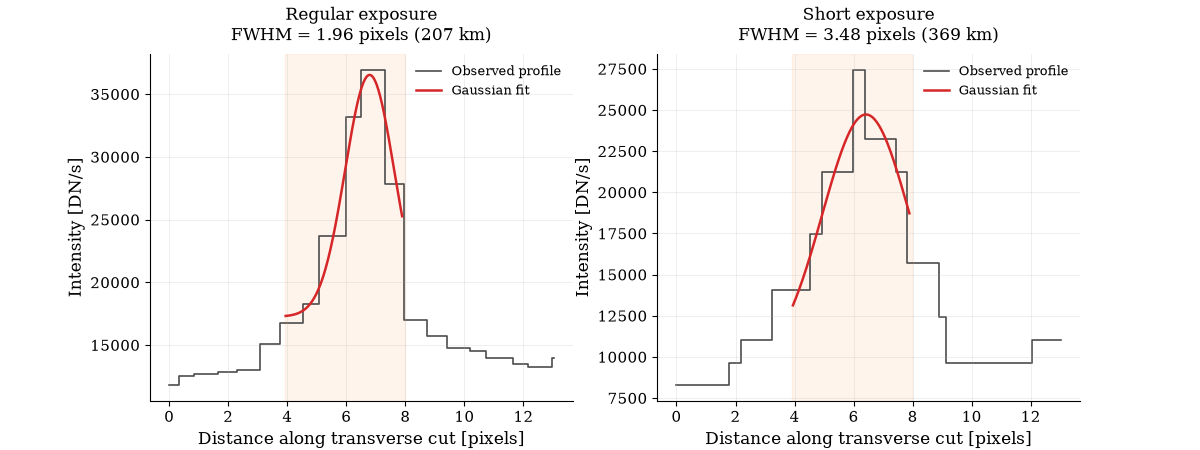

In [ ]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt


def gaussian(x, A, x0, sigma, B):
    return (
        A * np.exp(-(x - x0)**2 / (2 * sigma**2))
        + B
    )

fit_mask_2 = (
    (distance_2 >= 3.92) &
    (distance_2 <= 7.98)
)

x_loop_2 = distance_2[fit_mask_2]
y_loop_2 = intensity_2[fit_mask_2]

p0_2 = [
    y_loop_2.max() - y_loop_2.min(),
    x_loop_2[np.argmax(y_loop_2)],
    0.5,
    y_loop_2.min()
]

popt_2, pcov_2 = curve_fit(
    gaussian,
    x_loop_2,
    y_loop_2,
    p0=p0_2
)

A_2, x0_2, sigma_2, B_2 = popt_2

fwhm_pixels_2 = (
    2 * np.sqrt(2 * np.log(2)) *
    abs(sigma_2)
)



fit_mask_short_2 = (
    (short_distance_2 >= 3.92) &
    (short_distance_2 <= 7.98)
)

x_loop_short_2 = short_distance_2[fit_mask_short_2]
y_loop_short_2 = short_intensity_2[fit_mask_short_2]

p0_short_2 = [
    y_loop_short_2.max() - y_loop_short_2.min(),
    x_loop_short_2[np.argmax(y_loop_short_2)],
    0.5,
    y_loop_short_2.min()
]

popt_short_2, pcov_short_2 = curve_fit(
    gaussian,
    x_loop_short_2,
    y_loop_short_2,
    p0=p0_short_2
)

A_short_2, x0_short_2, sigma_short_2, B_short_2 = popt_short_2

fwhm_pixels_short_2 = (
    2 * np.sqrt(2 * np.log(2)) *
    abs(sigma_short_2)
)


print("REGULAR EXPOSURE")
print(f"Gaussian centre = {x0_2:.3f} pixels")
print(f"Sigma = {abs(sigma_2):.3f} pixels")
print(f"Background = {B_2:.2f} DN/s")
print(f"FWHM = {fwhm_pixels_2:.3f} pixels")

print("\nSHORT EXPOSURE")
print(f"Gaussian centre = {x0_short_2:.3f} pixels")
print(f"Sigma = {abs(sigma_short_2):.3f} pixels")
print(f"Background = {B_short_2:.2f} DN/s")
print(f"FWHM = {fwhm_pixels_short_2:.3f} pixels")



x_fit_2 = np.linspace(
    x_loop_2.min(),
    x_loop_2.max(),
    300
)

y_fit_2 = gaussian(
    x_fit_2,
    *popt_2
)


x_fit_short_2 = np.linspace(
    x_loop_short_2.min(),
    x_loop_short_2.max(),
    300
)

y_fit_short_2 = gaussian(
    x_fit_short_2,
    *popt_short_2
)


plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "font.family": "serif",
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

panel_data = [
    (axes[0], distance_2, intensity_2, x_loop_2, y_loop_2, x_fit_2, y_fit_2, fwhm_pixels_2, "Regular exposure"),
    (axes[1], short_distance_2, short_intensity_2, x_loop_short_2, y_loop_short_2,
     x_fit_short_2, y_fit_short_2, fwhm_pixels_short_2, "Short exposure"),
]

km_per_pixel = 106

for ax, dist, inten, x_loop, y_loop, x_fit, y_fit, fwhm, label in panel_data:

    #convert FWHM from pixels to km
    fwhm_km = fwhm * km_per_pixel

    ax.plot(
        dist,
        inten,
        drawstyle="steps-mid",
        color="0.3",
        linewidth=1.2,
        label="Observed profile",
        zorder=1
    )

    ax.plot(
        x_fit,
        y_fit,
        color="tab:red",
        linewidth=1.8,
        label="Gaussian fit",
        zorder=2
    )

    ax.axvspan(
        3.92,
        7.98,
        color="tab:orange",
        alpha=0.08,
        zorder=0
    )

    ax.set_xlabel("Distance along transverse cut [pixels]")
    ax.set_ylabel("Intensity [DN/s]")

    ax.set_title(
        f"{label}\n"
        f"FWHM = {fwhm:.2f} pixels ({fwhm_km:.0f} km)",
        pad=10
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.legend(frameon=False, loc="upper right")

In [144]:
print("SHORT LOOP 2 FIT")

print("Number of points:", len(x_loop_short_2))
print("Fit range:",
      x_loop_short_2.min(),
      "to",
      x_loop_short_2.max())

print("\nObserved peak:")
print("x =", x_loop_short_2[np.argmax(y_loop_short_2)])
print("y =", y_loop_short_2.max())

print("\nGaussian:")
print("x0 =", x0_short_2)
print("peak =", gaussian(
    x0_short_2,
    A_short_2,
    x0_short_2,
    sigma_short_2,
    B_short_2
))

print("\nFWHM =", fwhm_pixels_short_2)

SHORT LOOP 2 FIT
Number of points: 31
Fit range: 3.9446069457001807 to 7.889213891400361

Observed peak:
x = 6.048397316740277
y = 27445.898

Gaussian:
x0 = 6.418729212639277
peak = 24727.949194706736

FWHM = 3.4804572197166475


LOOP 3:

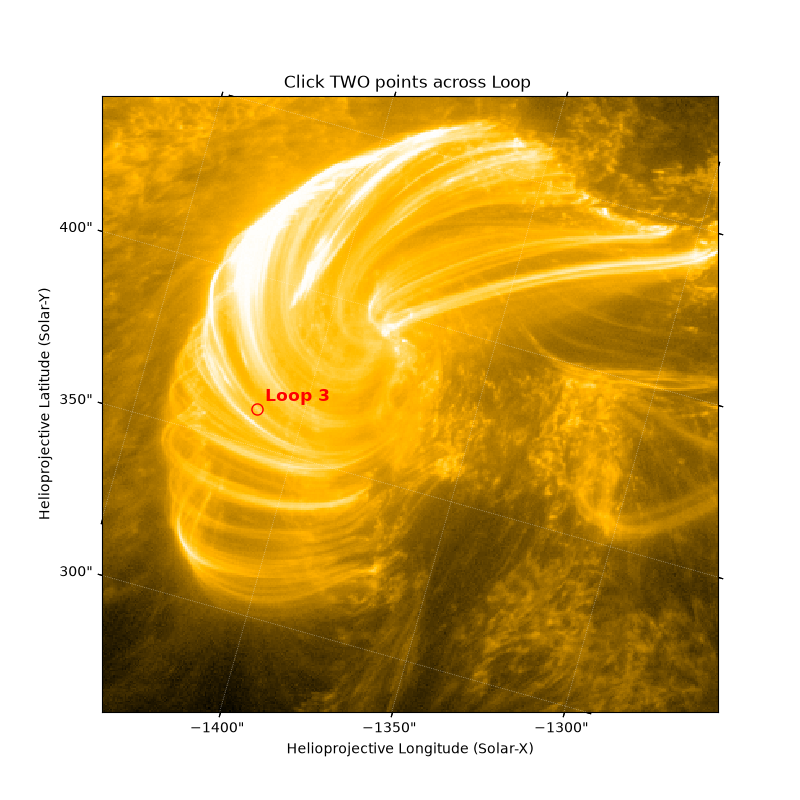

In [ ]:
clicked_points = []

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection=zoomed_map.wcs)

zoomed_map.plot(axes=ax)


loop3 = SkyCoord(
    -1414 * u.arcsec,
    361 * u.arcsec,
    frame=eui_map.coordinate_frame
)


x, y = zoomed_map.world_to_pixel(loop3)

ax.plot(
    x.value,
    y.value,
    "ro",
    markersize=8,
    markerfacecolor="none"
)

ax.text(
    x.value + 5,
    y.value + 5,
    "Loop 3",
    color="red",
    fontsize=12,
    fontweight="bold"
)

ax.set_title("Click TWO points across Loop ")

def onclick(event):
    if event.inaxes != ax:
        return

    if event.xdata is None or event.ydata is None:
        return

    if len(clicked_points) >= 2:
        return

    clicked_points.append((event.xdata, event.ydata))

    ax.plot(
        event.xdata,
        event.ydata,
        "go",
        markersize=8
    )

    ax.text(
        event.xdata + 3,
        event.ydata + 3,
        f"{len(clicked_points)}",
        color="green",
        fontsize=12,
        fontweight="bold"
    )

    fig.canvas.draw_idle()

    print(
        f"Point {len(clicked_points)}: "
        f"x={event.xdata:.2f}, y={event.ydata:.2f}"
    )

    if len(clicked_points) == 2:
        print("\nTwo points selected!")
        print("You can now use these to extract the transverse intensity profile.")

fig.canvas.mpl_connect("button_press_event", onclick)

plt.show()

Using the following transverse cut:
Point 1: x=60.37, y=262.63
Point 2: x=73.26, y=258.95


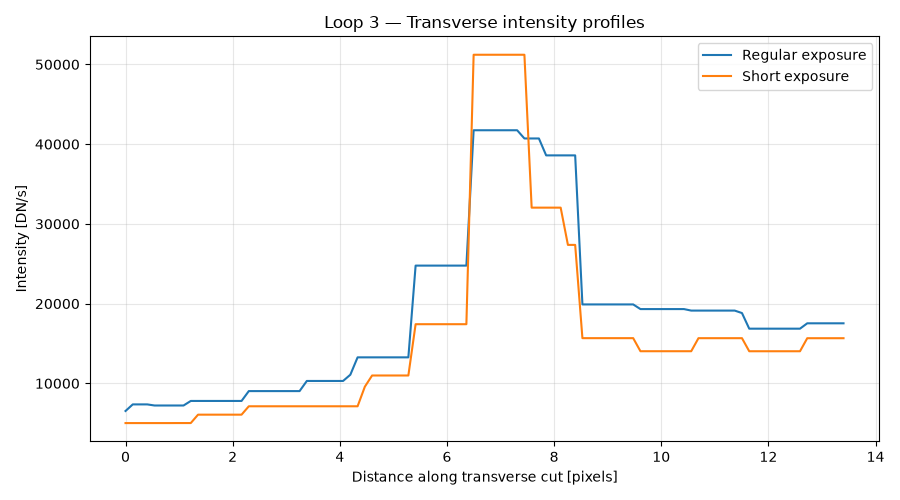

In [ ]:

import numpy as np
import matplotlib.pyplot as plt


if len(clicked_points) != 2:
    raise ValueError("Please click exactly TWO points first.")

(x1, y1), (x2, y2) = clicked_points

print("Using the following transverse cut:")
print(f"Point 1: x={x1:.2f}, y={y1:.2f}")
print(f"Point 2: x={x2:.2f}, y={y2:.2f}")


n_samples = 100

x_pixels = np.linspace(x1, x2, n_samples)
y_pixels = np.linspace(y1, y2, n_samples)

x_idx = np.round(x_pixels).astype(int)
y_idx = np.round(y_pixels).astype(int)

valid = (
    (x_idx >= 0) &
    (x_idx < zoomed_map.data.shape[1]) &
    (y_idx >= 0) &
    (y_idx < zoomed_map.data.shape[0])
)

x_idx = x_idx[valid]
y_idx = y_idx[valid]

intensity_3 = zoomed_map.data[y_idx, x_idx]

distance_3 = np.linspace(
    0,
    np.hypot(x2 - x1, y2 - y1),
    len(intensity_3)
)

import astropy.units as u

cut_coords_3 = zoomed_map.pixel_to_world(
    np.array([x1, x2]) * u.pix,
    np.array([y1, y2]) * u.pix
)

short_x1, short_y1 = short_zoom.world_to_pixel(cut_coords_3[0])
short_x2, short_y2 = short_zoom.world_to_pixel(cut_coords_3[1])

short_x1 = short_x1.value
short_y1 = short_y1.value
short_x2 = short_x2.value
short_y2 = short_y2.value


n_samples_short_3 = 100

short_x_pixels = np.linspace(
    short_x1,
    short_x2,
    n_samples_short_3
)

short_y_pixels = np.linspace(
    short_y1,
    short_y2,
    n_samples_short_3
)

short_x_idx = np.round(short_x_pixels).astype(int)
short_y_idx = np.round(short_y_pixels).astype(int)

valid = (
    (short_x_idx >= 0) &
    (short_x_idx < short_zoom.data.shape[1]) &
    (short_y_idx >= 0) &
    (short_y_idx < short_zoom.data.shape[0])
)

short_x_idx = short_x_idx[valid]
short_y_idx = short_y_idx[valid]

short_intensity_3 = short_zoom.data[
    short_y_idx,
    short_x_idx
]

short_distance_3 = np.linspace(
    0,
    np.hypot(short_x2 - short_x1, short_y2 - short_y1),
    len(short_intensity_3)
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    distance_3,
    intensity_3,
    linewidth=1.5,
    label="Regular exposure"
)

ax.plot(
    short_distance_3,
    short_intensity_3,
    linewidth=1.5,
    label="Short exposure"
)

ax.set_xlabel("Distance along transverse cut [pixels]")
ax.set_ylabel("Intensity [DN/s]")
ax.set_title("Loop 3 — Transverse intensity profiles")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../figures/loop3_transverse_profiles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

REGULAR EXPOSURE
FWHM = 120.823 pixels
sigma = 51.309

SHORT EXPOSURE
FWHM = 1.118 pixels
sigma = 0.475


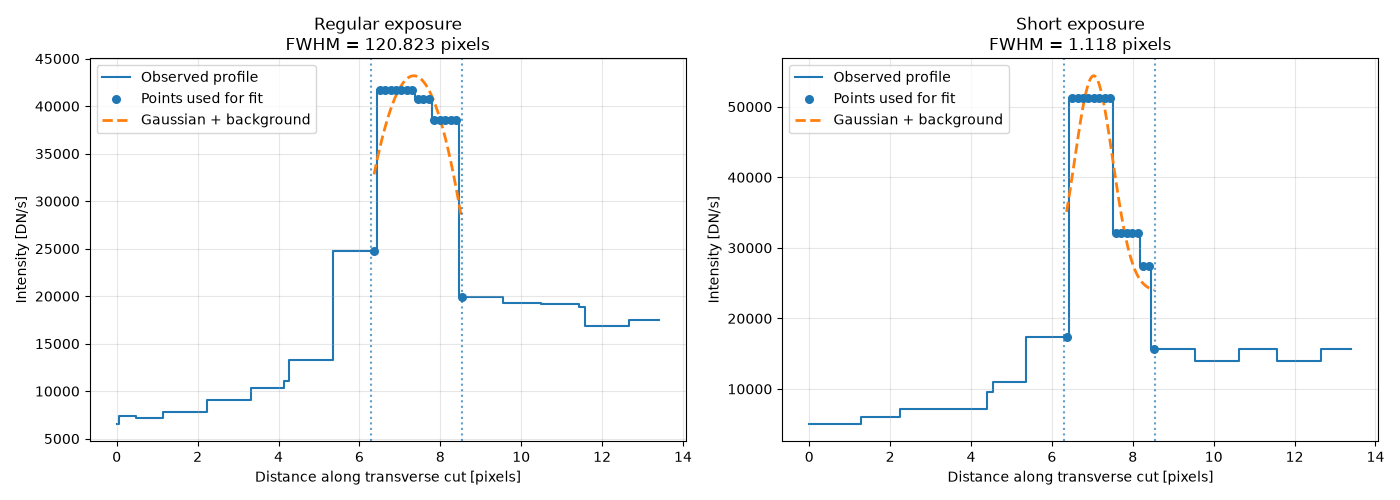

In [ ]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt


def gaussian(x, A, x0, sigma, B):
    return (
        A * np.exp(-(x - x0)**2 / (2 * sigma**2))
        + B
    )


fit_mask_3 = (
    (distance_3 >= 6.29) &
    (distance_3 <= 8.54)
)

x_loop_3 = distance_3[fit_mask_3]
y_loop_3 = intensity_3[fit_mask_3]

p0_3 = [
    y_loop_3.max() - y_loop_3.min(),
    x_loop_3[np.argmax(y_loop_3)],
    0.5,
    y_loop_3.min()
]

popt_3, pcov_3 = curve_fit(
    gaussian,
    x_loop_3,
    y_loop_3,
    p0=p0_3
)

A_3, x0_3, sigma_3, B_3 = popt_3

fwhm_pixels_3 = (
    2 * np.sqrt(2 * np.log(2)) *
    abs(sigma_3)
)


x_fit_3 = np.linspace(
    x_loop_3.min(),
    x_loop_3.max(),
    300
)

y_fit_3 = gaussian(
    x_fit_3,
    A_3,
    x0_3,
    sigma_3,
    B_3
)


fit_mask_short_3 = (
    (short_distance_3 >= 6.29) &
    (short_distance_3 <= 8.54)
)

x_loop_short_3 = short_distance_3[fit_mask_short_3]
y_loop_short_3 = short_intensity_3[fit_mask_short_3]

p0_short_3 = [
    y_loop_short_3.max() - y_loop_short_3.min(),
    x_loop_short_3[np.argmax(y_loop_short_3)],
    0.5,
    y_loop_short_3.min()
]

popt_short_3, pcov_short_3 = curve_fit(
    gaussian,
    x_loop_short_3,
    y_loop_short_3,
    p0=p0_short_3
)

A_short_3, x0_short_3, sigma_short_3, B_short_3 = popt_short_3

fwhm_pixels_short_3 = (
    2 * np.sqrt(2 * np.log(2)) *
    abs(sigma_short_3)
)


x_fit_short_3 = np.linspace(
    x_loop_short_3.min(),
    x_loop_short_3.max(),
    300
)

y_fit_short_3 = gaussian(
    x_fit_short_3,
    A_short_3,
    x0_short_3,
    sigma_short_3,
    B_short_3
)

print("REGULAR EXPOSURE")
print(f"FWHM = {fwhm_pixels_3:.3f} pixels")
print(f"sigma = {sigma_3:.3f}")

print("\nSHORT EXPOSURE")
print(f"FWHM = {fwhm_pixels_short_3:.3f} pixels")
print(f"sigma = {sigma_short_3:.3f}")


fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5),
    sharey=False
)


ax = axes[0]

ax.plot(
    distance_3,
    intensity_3,
    drawstyle="steps-mid",
    linewidth=1.5,
    label="Observed profile",
    zorder=1
)

ax.scatter(
    x_loop_3,
    y_loop_3,
    s=30,
    label="Points used for fit",
    zorder=3
)

ax.plot(
    x_fit_3,
    y_fit_3,
    "--",
    linewidth=2,
    label="Gaussian + background",
    zorder=2
)

ax.axvline(
    6.29,
    linestyle=":",
    alpha=0.7
)

ax.axvline(
    8.54,
    linestyle=":",
    alpha=0.7
)

ax.set_xlabel("Distance along transverse cut [pixels]")
ax.set_ylabel("Intensity [DN/s]")

ax.set_title(
    f"Regular exposure\n"
    f"FWHM = {fwhm_pixels_3:.3f} pixels"
)

ax.legend()
ax.grid(alpha=0.3)


ax = axes[1]

ax.plot(
    short_distance_3,
    short_intensity_3,
    drawstyle="steps-mid",
    linewidth=1.5,
    label="Observed profile",
    zorder=1
)

ax.scatter(
    x_loop_short_3,
    y_loop_short_3,
    s=30,
    label="Points used for fit",
    zorder=3
)

ax.plot(
    x_fit_short_3,
    y_fit_short_3,
    "--",
    linewidth=2,
    label="Gaussian + background",
    zorder=2
)

ax.axvline(
    6.29,
    linestyle=":",
    alpha=0.7
)

ax.axvline(
    8.54,
    linestyle=":",
    alpha=0.7
)

ax.set_xlabel("Distance along transverse cut [pixels]")
ax.set_ylabel("Intensity [DN/s]")

ax.set_title(
    f"Short exposure\n"
    f"FWHM = {fwhm_pixels_short_3:.3f} pixels"
)

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../figures/loop3_gaussian_fit_both.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Regular profile not Gaussian shaped so unreliable fit.

LOOP 4:

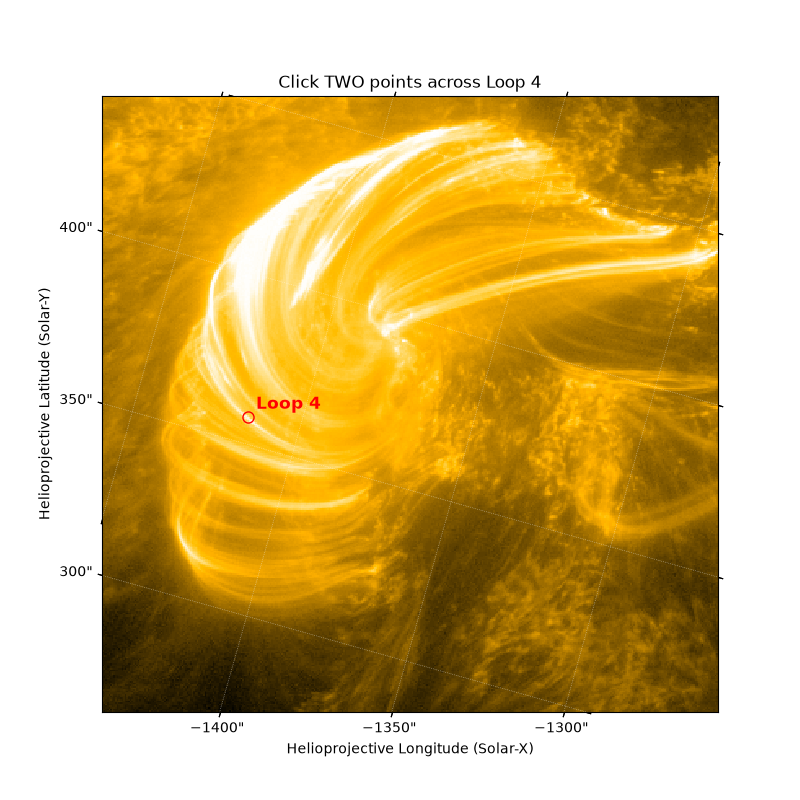

In [ ]:
clicked_points = []

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection=zoomed_map.wcs)

zoomed_map.plot(axes=ax)

loop4 = SkyCoord(
    -1416 * u.arcsec,
    358 * u.arcsec,
    frame=eui_map.coordinate_frame
)

x, y = zoomed_map.world_to_pixel(loop4)

ax.plot(
    x.value,
    y.value,
    "ro",
    markersize=8,
    markerfacecolor="none"
)

ax.text(
    x.value + 5,
    y.value + 5,
    "Loop 4",
    color="red",
    fontsize=12,
    fontweight="bold"
)

ax.set_title("Click TWO points across Loop 4")

def onclick(event):
    if event.inaxes != ax:
        return

    if event.xdata is None or event.ydata is None:
        return

    if len(clicked_points) >= 2:
        return

    clicked_points.append((event.xdata, event.ydata))

    ax.plot(
        event.xdata,
        event.ydata,
        "go",
        markersize=8
    )

    ax.text(
        event.xdata + 3,
        event.ydata + 3,
        f"{len(clicked_points)}",
        color="green",
        fontsize=12,
        fontweight="bold"
    )

    fig.canvas.draw_idle()

    print(
        f"Point {len(clicked_points)}: "
        f"x={event.xdata:.2f}, y={event.ydata:.2f}"
    )

    if len(clicked_points) == 2:
        print("\nTwo points selected!")
        print("You can now use these to extract the transverse intensity profile.")

fig.canvas.mpl_connect("button_press_event", onclick)

plt.show()

In [151]:
import numpy as np
import matplotlib.pyplot as plt

(x1, y1), (x2, y2) = clicked_points

n_samples = int(np.hypot(x2 - x1, y2 - y1)) * 2

x_pixels = np.linspace(x1, x2, n_samples)
y_pixels = np.linspace(y1, y2, n_samples)

x_idx = np.round(x_pixels).astype(int)
y_idx = np.round(y_pixels).astype(int)

valid = (
    (x_idx >= 0) &
    (x_idx < zoomed_map.data.shape[1]) &
    (y_idx >= 0) &
    (y_idx < zoomed_map.data.shape[0])
)

x_idx = x_idx[valid]
y_idx = y_idx[valid]

intensity_4 = zoomed_map.data[y_idx, x_idx]

distance_4 = np.linspace(
    0,
    np.hypot(x2 - x1, y2 - y1),
    len(intensity_4)
)

import astropy.units as u

cut_coords_4 = zoomed_map.pixel_to_world(
    np.array([x1, x2]) * u.pix,
    np.array([y1, y2]) * u.pix
)

short_x1, short_y1 = short_zoom.world_to_pixel(cut_coords_4[0])
short_x2, short_y2 = short_zoom.world_to_pixel(cut_coords_4[1])

short_x1 = short_x1.value
short_y1 = short_y1.value
short_x2 = short_x2.value
short_y2 = short_y2.value

n_samples_short_4 = int(
    np.hypot(short_x2 - short_x1, short_y2 - short_y1)
) * 2

short_x_pixels = np.linspace(
    short_x1,
    short_x2,
    n_samples_short_4
)

short_y_pixels = np.linspace(
    short_y1,
    short_y2,
    n_samples_short_4
)

short_x_idx = np.round(short_x_pixels).astype(int)
short_y_idx = np.round(short_y_pixels).astype(int)

valid = (
    (short_x_idx >= 0) &
    (short_x_idx < short_zoom.data.shape[1]) &
    (short_y_idx >= 0) &
    (short_y_idx < short_zoom.data.shape[0])
)

short_x_idx = short_x_idx[valid]
short_y_idx = short_y_idx[valid]

short_intensity_4 = short_zoom.data[
    short_y_idx,
    short_x_idx
]

short_distance_4 = np.linspace(
    0,
    np.hypot(short_x2 - short_x1, short_y2 - short_y1),
    len(short_intensity_4)
)


fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    distance_4,
    intensity_4,
    linewidth=1.5,
    drawstyle="steps-mid",
    label="Regular exposure"
)

ax.plot(
    short_distance_4,
    short_intensity_4,
    linewidth=1.5,
    drawstyle="steps-mid",
    label="Short exposure"
)

ax.set_xlabel("Distance along transverse cut [pixels]")
ax.set_ylabel("Intensity [DN/s]")
ax.set_title("Loop 4 — Transverse intensity profiles")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../figures/loop4_transverse_profiles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ValueError: not enough values to unpack (expected 2, got 0)

Regular points used: 5
Short points used: 5

REGULAR EXPOSURE
Gaussian centre = 6.882 pixels
Sigma = 1.957 pixels
Background = -52055.98 DN/s
FWHM = 4.609 pixels

SHORT EXPOSURE
Gaussian centre = 6.530 pixels
Sigma = 38.694 pixels
Background = -18306783.44 DN/s
FWHM = 91.118 pixels


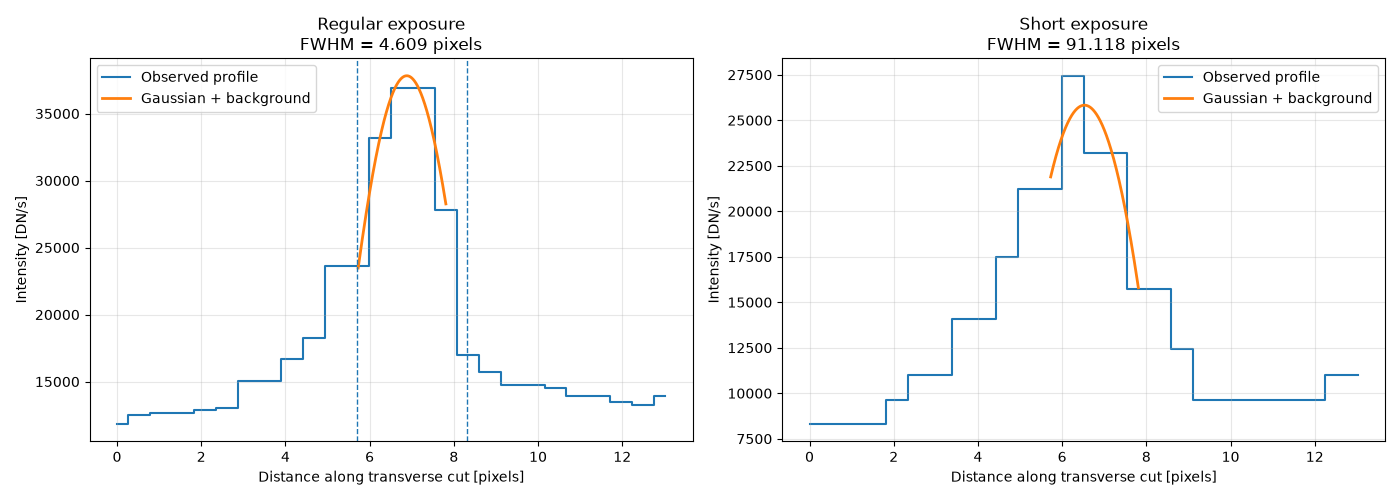

In [ ]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt


def gaussian(x, A, x0, sigma, B):
    return (
        A * np.exp(-(x - x0)**2 / (2 * sigma**2))
        + B
    )


fit_mask_4 = (
    (distance_4 >= 5.70) &
    (distance_4 <= 8.32)
)

x_loop_4 = distance_4[fit_mask_4]
y_loop_4 = intensity_4[fit_mask_4]

print(f"Regular points used: {len(x_loop_4)}")

p0_4 = [
    y_loop_4.max() - y_loop_4.min(),
    x_loop_4[np.argmax(y_loop_4)],
    0.5,
    y_loop_4.min()
]

popt_4, pcov_4 = curve_fit(
    gaussian,
    x_loop_4,
    y_loop_4,
    p0=p0_4
)

A_4, x0_4, sigma_4, B_4 = popt_4

fwhm_pixels_4 = (
    2 * np.sqrt(2 * np.log(2)) *
    abs(sigma_4)
)


fit_mask_short_4 = (
    (short_distance_4 >= 5.70) &
    (short_distance_4 <= 8.32)
)

x_loop_short_4 = short_distance_4[fit_mask_short_4]
y_loop_short_4 = short_intensity_4[fit_mask_short_4]

print(f"Short points used: {len(x_loop_short_4)}")

p0_short_4 = [
    y_loop_short_4.max() - y_loop_short_4.min(),
    x_loop_short_4[np.argmax(y_loop_short_4)],
    0.5,
    y_loop_short_4.min()
]

popt_short_4, pcov_short_4 = curve_fit(
    gaussian,
    x_loop_short_4,
    y_loop_short_4,
    p0=p0_short_4
)

A_short_4, x0_short_4, sigma_short_4, B_short_4 = popt_short_4

fwhm_pixels_short_4 = (
    2 * np.sqrt(2 * np.log(2)) *
    abs(sigma_short_4)
)

print("\nREGULAR EXPOSURE")
print(f"Gaussian centre = {x0_4:.3f} pixels")
print(f"Sigma = {abs(sigma_4):.3f} pixels")
print(f"Background = {B_4:.2f} DN/s")
print(f"FWHM = {fwhm_pixels_4:.3f} pixels")

print("\nSHORT EXPOSURE")
print(f"Gaussian centre = {x0_short_4:.3f} pixels")
print(f"Sigma = {abs(sigma_short_4):.3f} pixels")
print(f"Background = {B_short_4:.2f} DN/s")
print(f"FWHM = {fwhm_pixels_short_4:.3f} pixels")


x_fit_4 = np.linspace(
    x_loop_4.min(),
    x_loop_4.max(),
    300
)

y_fit_4 = gaussian(
    x_fit_4,
    *popt_4
)


x_fit_short_4 = np.linspace(
    x_loop_short_4.min(),
    x_loop_short_4.max(),
    300
)

y_fit_short_4 = gaussian(
    x_fit_short_4,
    *popt_short_4
)


fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5)
)


ax = axes[0]

ax.plot(
    distance_4,
    intensity_4,
    linewidth=1.5,
    drawstyle="steps-mid",
    label="Observed profile",
    zorder=1
)


ax.plot(
    x_fit_4,
    y_fit_4,
    linewidth=2,
    label="Gaussian + background",
    zorder=2
)

ax.axvline(
    5.70,
    linestyle="--",
    linewidth=1
)

ax.axvline(
    8.32,
    linestyle="--",
    linewidth=1
)

ax.set_xlabel("Distance along transverse cut [pixels]")
ax.set_ylabel("Intensity [DN/s]")

ax.set_title(
    f"Regular exposure\n"
    f"FWHM = {fwhm_pixels_4:.3f} pixels"
)

ax.legend()
ax.grid(alpha=0.3)


ax = axes[1]

ax.plot(
    short_distance_4,
    short_intensity_4,
    linewidth=1.5,
    drawstyle="steps-mid",
    label="Observed profile",
    zorder=1
)


ax.plot(
    x_fit_short_4,
    y_fit_short_4,
    linewidth=2,
    label="Gaussian + background",
    zorder=2
)


ax.set_xlabel("Distance along transverse cut [pixels]")
ax.set_ylabel("Intensity [DN/s]")

ax.set_title(
    f"Short exposure\n"
    f"FWHM = {fwhm_pixels_short_4:.3f} pixels"
)

ax.legend()
ax.grid(alpha=0.3)


plt.tight_layout()

plt.savefig(
    "../figures/loop4_gaussian_fit_both.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import pandas as pd
import numpy as np

#conversion from EUI pixels to physical distance
km_per_pixel = 106  # km/pixel

results = pd.DataFrame({
    "Loop": [1, 2, 3, 4],

    "Regular FWHM [pixels]": [
        fwhm_pixels_1,
        fwhm_pixels_2,
        fwhm_pixels_3,
        fwhm_pixels_4
    ],


    "Short FWHM [pixels]": [
        np.nan,
        fwhm_pixels_short_2,
        fwhm_pixels_short_3,
        fwhm_pixels_short_4
    ]
})


results["Regular FWHM [km]"] = (
    results["Regular FWHM [pixels]"] * km_per_pixel
)

results["Short FWHM [km]"] = (
    results["Short FWHM [pixels]"] * km_per_pixel
)


results["Regular FWHM [pixels]"] = (
    results["Regular FWHM [pixels]"].round(3)
)

results["Short FWHM [pixels]"] = (
    results["Short FWHM [pixels]"].round(3)
)

results["Regular FWHM [km]"] = (
    results["Regular FWHM [km]"].round(1)
)

results["Short FWHM [km]"] = (
    results["Short FWHM [km]"].round(1)
)


results

,Loop,Regular FWHM [pixels],Short FWHM [pixels],Regular FWHM [km],Short FWHM [km]
0,1,152.131,NaN,16125.8,NaN
1,2,1.955,3.480,207.3,368.9
2,3,120.823,1.118,12807.2,118.5
3,4,4.609,91.118,488.6,9658.6
